**Names of both participants:** Mohammadi Jalal & Nate Rathjen

**Unity IDs**:Msjalal, ncrathje

**Each member’s contributions**:

**Mohammadi Jalal**: Completed importing dataset, preprocessing, exploratory analysis, Business insights EDA, train/test, with Questions and build descision tree model, and worked on streamlit application.

**Nate Rathjen**: Build Logistic regression model, answered logistic regression, comparison, and recommendation questions.

# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [ ]:


from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
path="/content/loan_data_analysis_final.csv"

df=pd.read_csv(path)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Check first 5 rows of dataframe
df.head(5)

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [ ]:
# 1. Identify columns with no variation (constant values)
# By default, nunique() ignores NaNs. We set dropna=False to be safe.
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]

# 2. Identify columns where every value is unique (like User ID)
unique_cols = [col for col in df.columns if df[col].nunique() == len(df)]

# Combine the lists
cols_to_drop = list(set(constant_cols + unique_cols))

# Display the findings before dropping
print(f"Columns with no variation: {constant_cols}")
print(f"Unique/ID columns: {unique_cols}")

Columns with no variation: ['applications']
Unique/ID columns: ['User ID']


In [ ]:
# drop the columns
df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
#verifying
df.head(5)

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [ ]:
# 1. shows data types, rows and colums
df.info()
# shows the numerical summary like mean, median
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtypes: float64(3), 

,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,85000.000000,85000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,629.338153,5808.783776,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,88.684201,2988.185274,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.000000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,572.000000,3659.000000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,634.000000,5153.500000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,693.000000,7612.000000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.000000,49500.000000,1.000000,1.000000,350.000000


In [ ]:
# shows categorical variables that might need encoding to turn them into numerical data
df.describe(include=['object'])

,Reason,Fico_Score_group,Employment_Status,Employment_Sector,Lender
count,100000,100000,100000,93593,100000
unique,6,5,3,11,3
top,debt_conslidation,fair,full_time,information_technology,A
freq,27622,36475,76530,19748,55000


Based on the output 4 categorical variables need encoding they are reason (has many reasons), employment status(parttime, full time), lender (A,B and C) and  employment sector(IT , energy and many more)

## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Median is preferable because it gives median center values rather than high average which is skewed towards high income or high fico score people who comes for loan approval process. So using median help us prevent bias towards high income people whose loan get approved quickly based on these factors, compared to people with low or median fico score and income.





In [ ]:
# Inspect missing values
df.isnull().sum()


,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,15000
Fico_Score_group,0
Employment_Status,0
Employment_Sector,6407
Monthly_Gross_Income,15000
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0


There is missing values in FICO score, employment sector and monthly gross income, to remove missing values we cannot drop the data as it creates imbalance to the dataset but need to apply amputation to balance it

In [ ]:
  # Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

  # Impute FICO_score with median
  df['FICO_score'] = df['FICO_score'].fillna(df['FICO_score'].median())

  # Impute Monthly_Gross_Income with median
  df['Monthly_Gross_Income'] = df['Monthly_Gross_Income'].fillna(df['Monthly_Gross_Income'].median())

  # Impute Employment_Sector with 'Unknown'
  df['Employment_Sector'] = df['Employment_Sector'].fillna('Unknown')

  print('Missing values after imputation:')
  print(df.isnull().sum())

Missing values after imputation:
Reason                        0
Granted_Loan_Amount           0
Requested_Loan_Amount         0
FICO_score                    0
Fico_Score_group              0
Employment_Status             0
Employment_Sector             0
Monthly_Gross_Income          0
Monthly_Housing_Payment       0
Ever_Bankrupt_or_Foreclose    0
Lender                        0
Approved                      0
bounty                        0
dtype: int64


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : Based on imputation we did the monthly gross income and FICO scores are the variables that might have most outliers. outlier for descsion tree means for one unusual extreme value it can create whole new leaf to  capture the outlier that is why we need to ensure maxdepth is set to specific number so that they can look overall trend rather than looking each individual variable. Additionally, this also happens with logistic regression as it can shift the curve just for to capture outlier so it is very important to remove outliers so it can improve our model performance and reliability before any traing and testing happens.

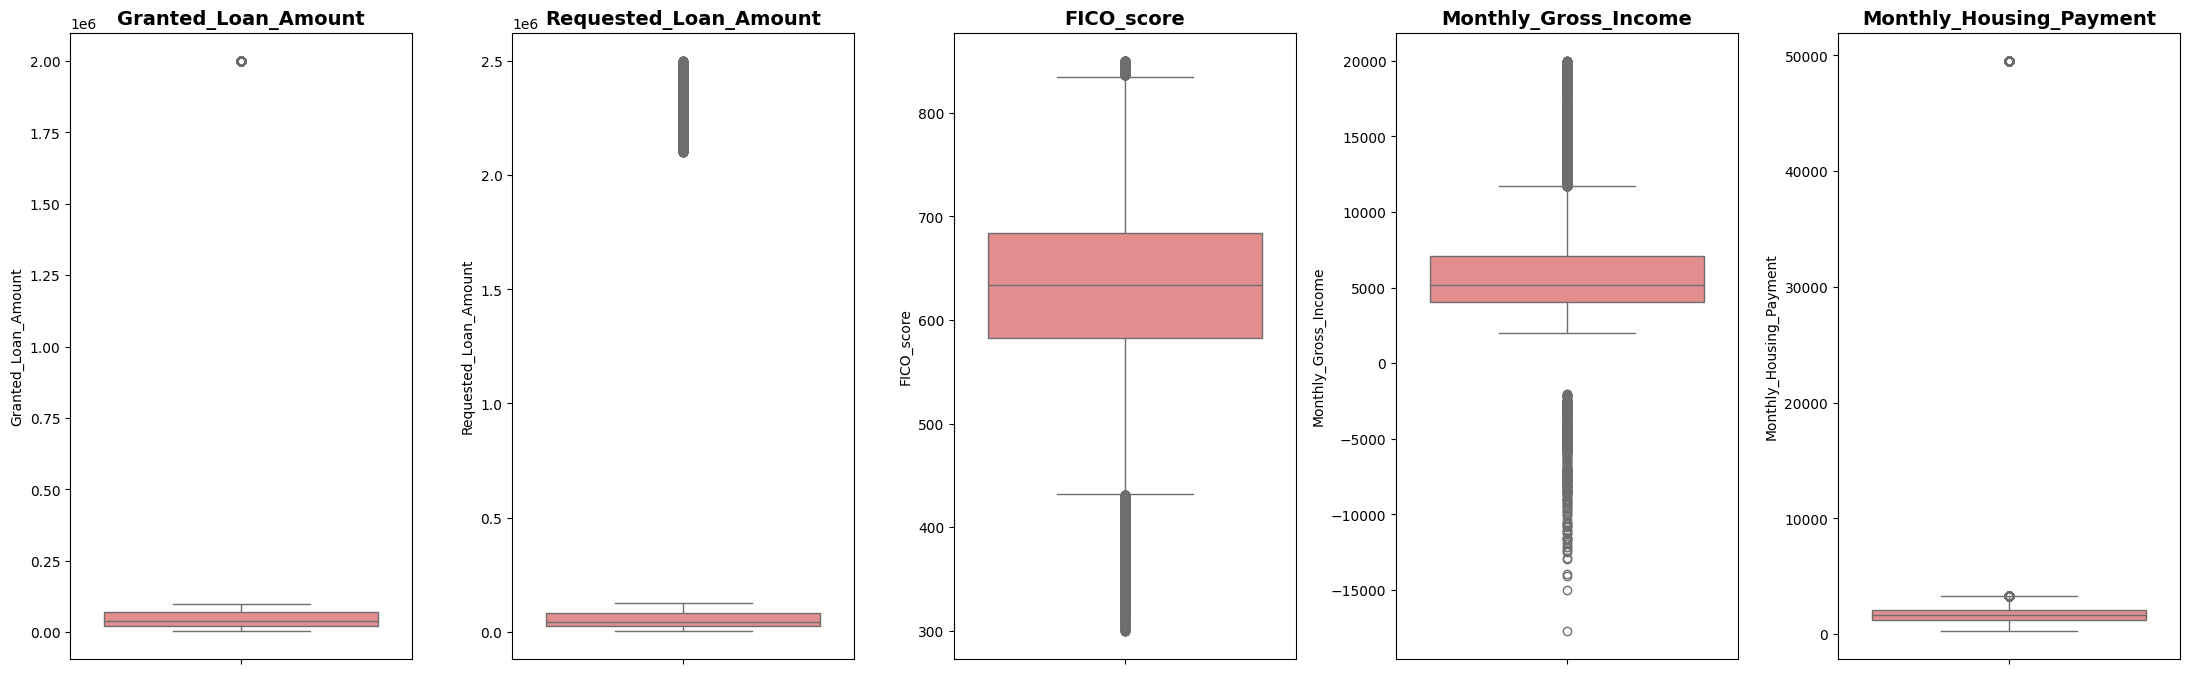

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
# Set up the figure for multiple subplots
fig, axes = plt.subplots(1, 5, figsize=(22, 7))

# Create boxplots
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")



Outlier removal complete:
Rows before: 100000
Rows after:  95691
Rows removed: 4309


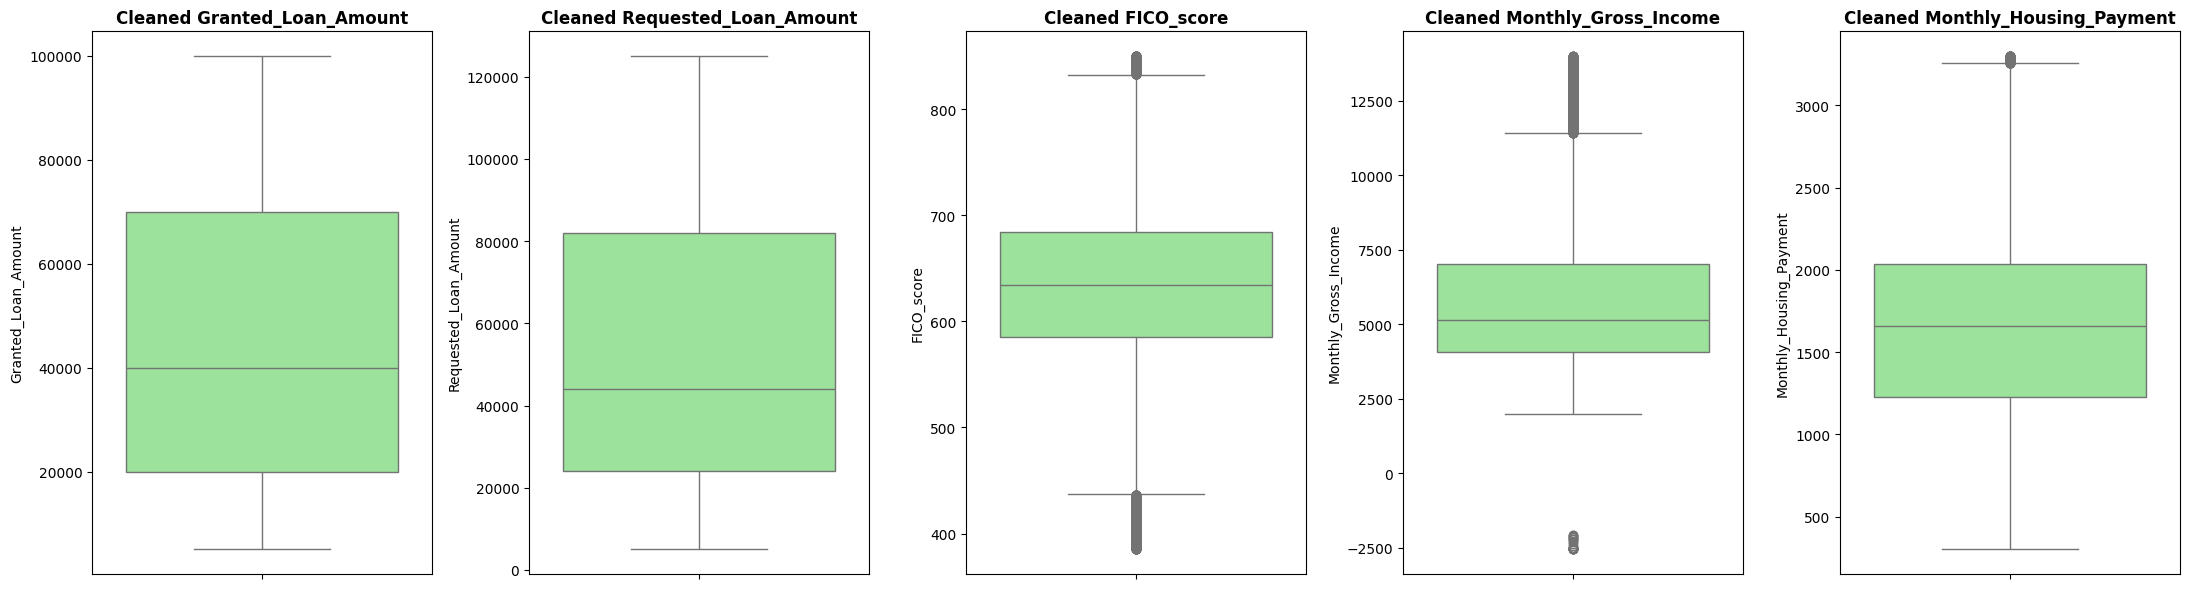

In [ ]:
# BoxPlots after outlier removal
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']
# 2. Set up the plotting area (1 row, 5 columns)
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

# 3. Loop through the columns and plot the CLEANED data
# Assuming your cleaned dataframe is named 'df_clean'
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Cleaned {col}', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()


**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Outliers can significantly skew mean and standard deviation, which models like Logistic Regression (lasso) rely on for scaling and coefficient estimation. They can also lead to overfitting, where the model hallucinate and create unrealistic outcome rather than learning patterns. Lasty,removing  ouliers can improve improves the model performace


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes, there is a difference in box plots. Before oultier removal all numerical columns had ouliers which condense the visual without clear interpretation for example for guaranteed loan amount and requested loan amount between 0.00 to 0.25 without explaing context due to extreme outliers but as we removed it through z-scores we were able to interpret that 22000 to 65000 is guranteed amount and requested loan amount could be upto 80000 leading to more clear visual of how removing olters can make everything very clear and easy to interpret.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** Requested_loan_amount and Guaranteed_loan_amount appear strongly correlated (1.00) with each other.This shows multicollinearity so we have to drop one.



**Question:**
Which numerical and categorical variables are strongly correlated?

**Answer:** FICO Score and FICO_score group are highly appear strongly correlated (0.85). This signify multicolleaniry so we can only keep one variable.


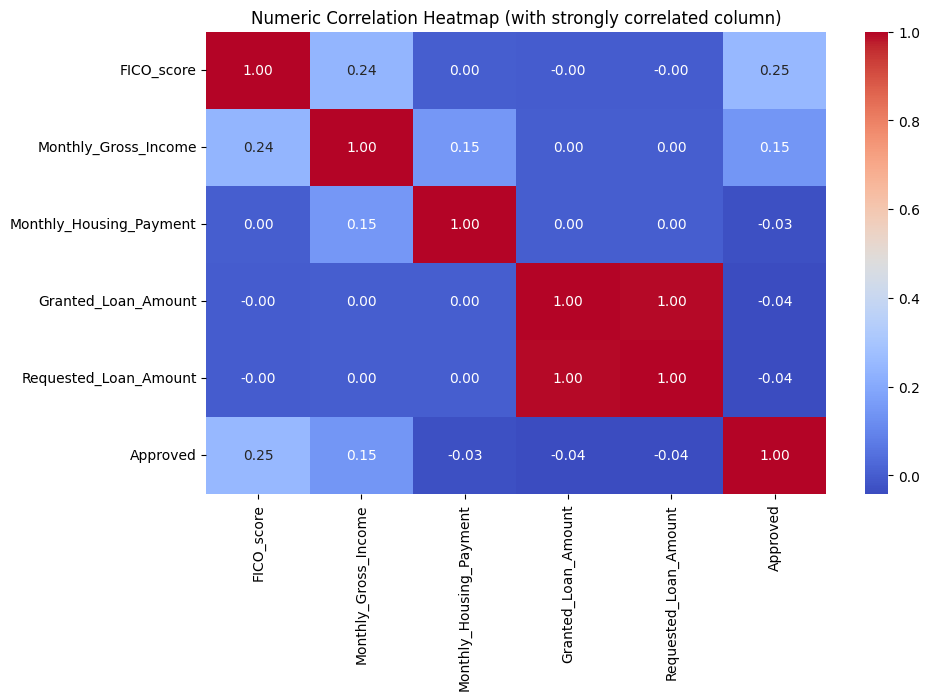

In [ ]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.729 (η = 0.854)
Monthly_Gross_Income - Employment_Status: η² = 0.246 (η = 0.496)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Employment_Sector: η² = 0.070 (η = 0.265)
Monthly_Housing_Payment - Employment_Status: η² = 0.039 (η = 0.198)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.169)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.026 (η = 0.162)
Monthly_Gross_Income - Lender: η² = 0.008 (η = 0.090)
Ever_Bankrupt_or_Foreclose - Lender: η² = 0.005 (η = 0.071)


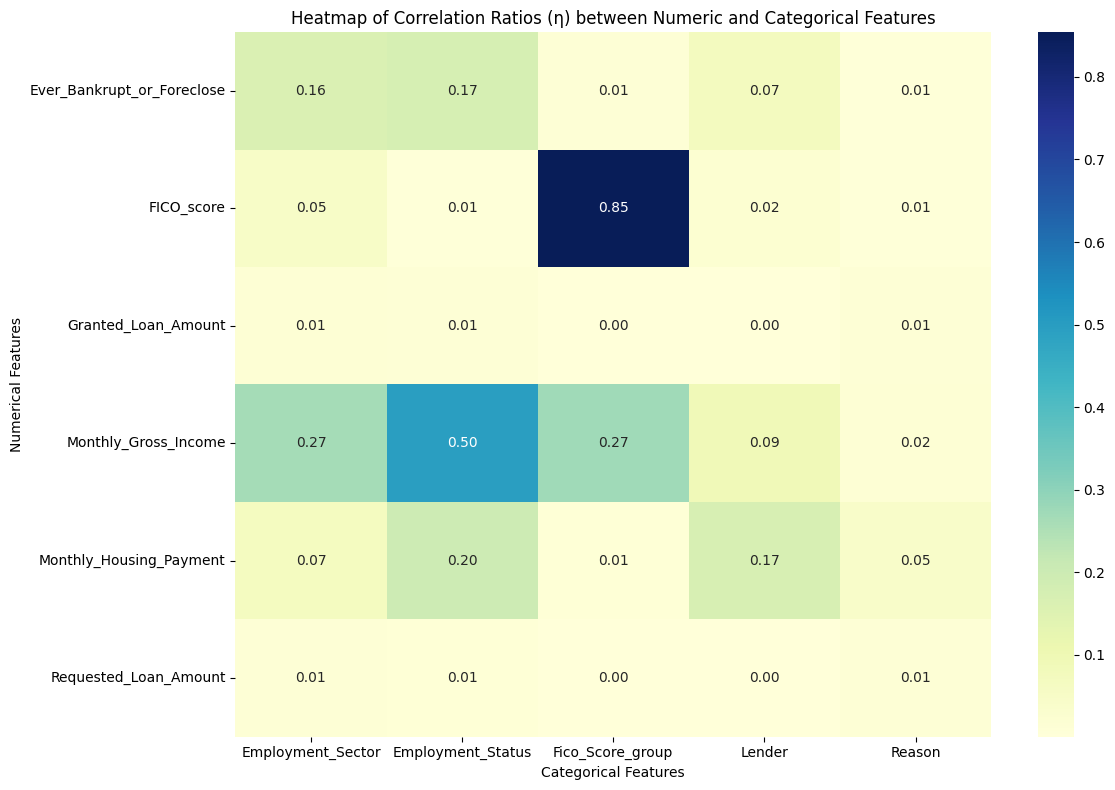

In [ ]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()



**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : For numerical variables, I would recommend dropping requested loan amount as banks often guaranteed loan amount based on customers' needs or requests. For exampley they ask $20000 to open a bakery and they usually get that amount. For numerical & categorical variable, I would suggest to remove categorical fico_score_group because loan is approved if they have meet certain fico score and numerical score is better for models to interpret rather than just excellent or good when creating and deciding which models to use for loan approval application process.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
This dataset is highly imbalanced as 89% of applications are denied and 11% of applications are approved for loan approvals. If we create models based on this then models will only learn to be biased toward majority like denied loan approvals compared to approving loans.

Counts:
 Approved
0    85309
1    10382
Name: count, dtype: int64

Percentages:
 Approved
0    89.150495
1    10.849505
Name: proportion, dtype: float64


/tmp/ipykernel_3764/291568769.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df, palette='Set2')


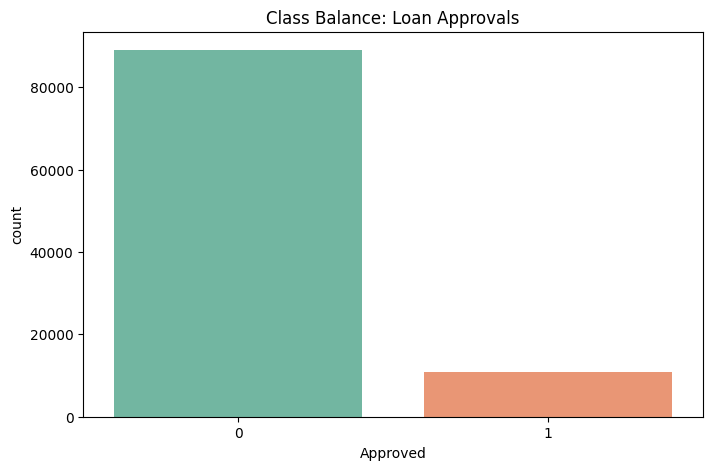

In [ ]:
# Plot 'Approved' to visualise the count and balance
# Calculate frequency counts
counts = df_clean['Approved'].value_counts()
# Calculate percentages
percentages = df_clean['Approved'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percentages)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='Approved', data=df, palette='Set2')
plt.title('Class Balance: Loan Approvals')
plt.show()

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
Based on viualizations below I would say FICO Score is most helpful numerical variable as it help to define weather loan would approve or denied through clear separation between approved and denied groups in histogram and boxplots for example,  I saw that FICO score above 690 to 800 gets loan approved in histogram and in box plot is between 620 to 710 fico score.Lastly, in multicolinearity step above, the FICO score was between 620 and 710. Lastly, in then multicolinearity step above, the FICO score was between 620 and 710. Lastly, in multicolinearity step above ficor score was most crucial numerical predictor for loan approval process.


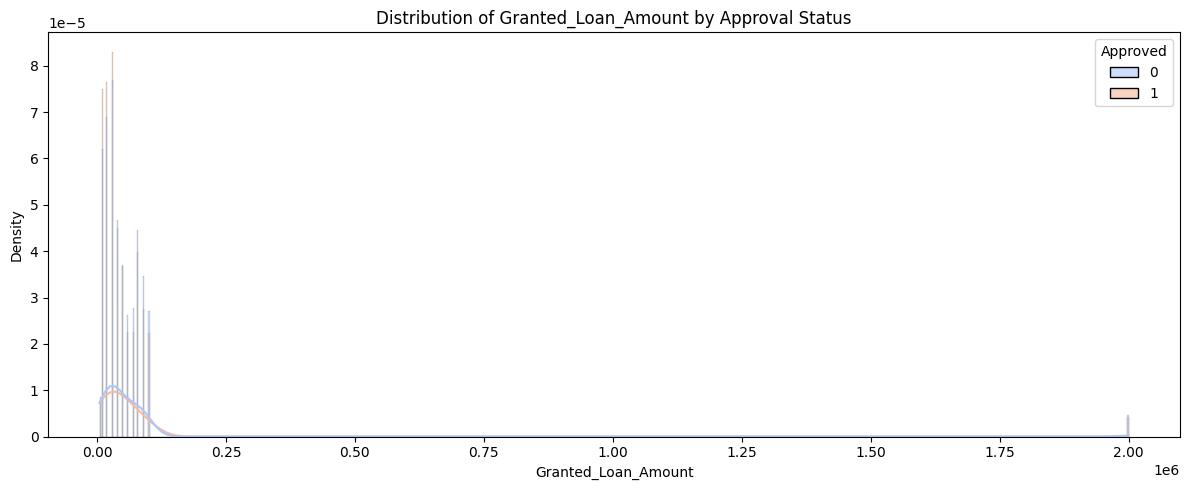

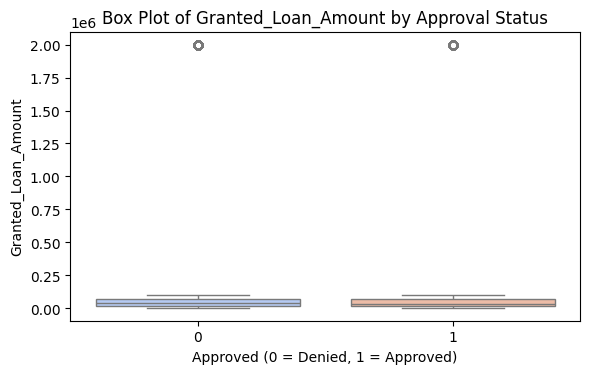

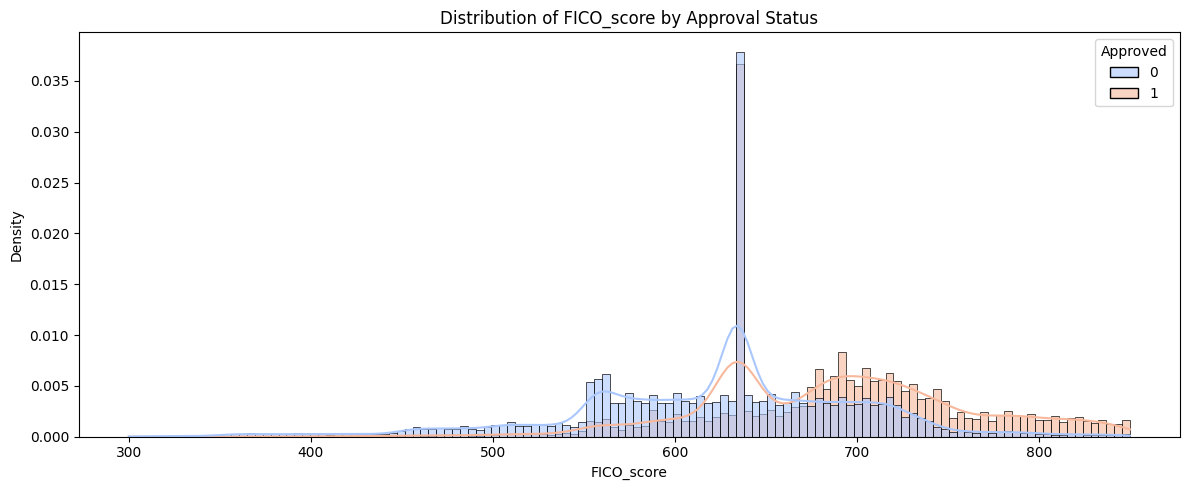

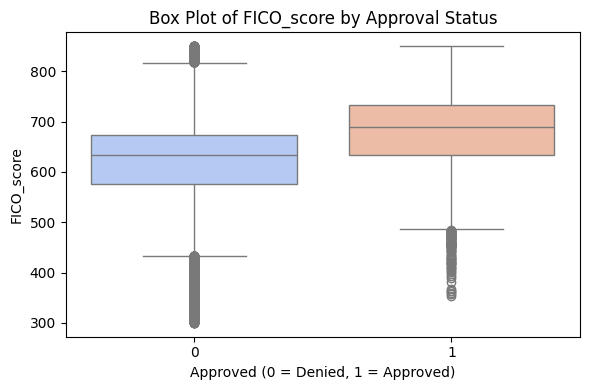

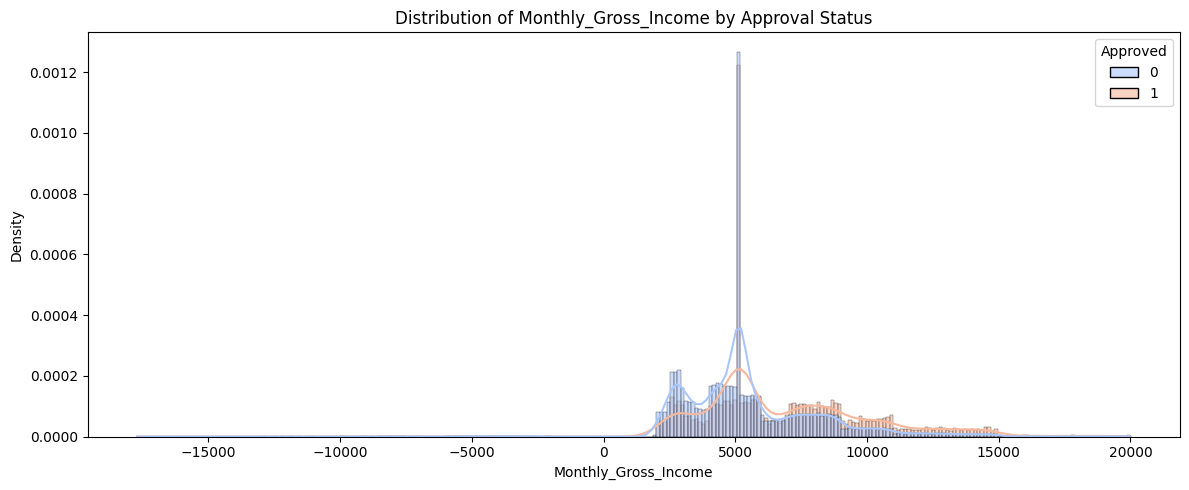

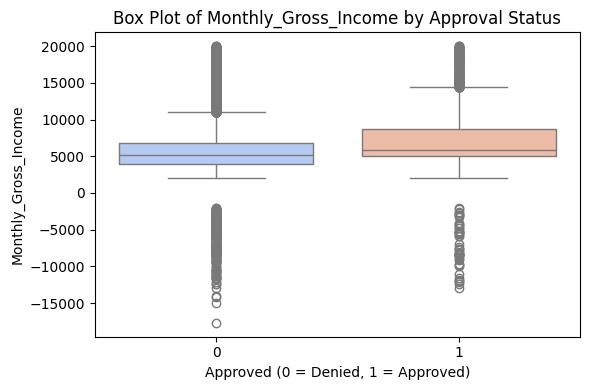

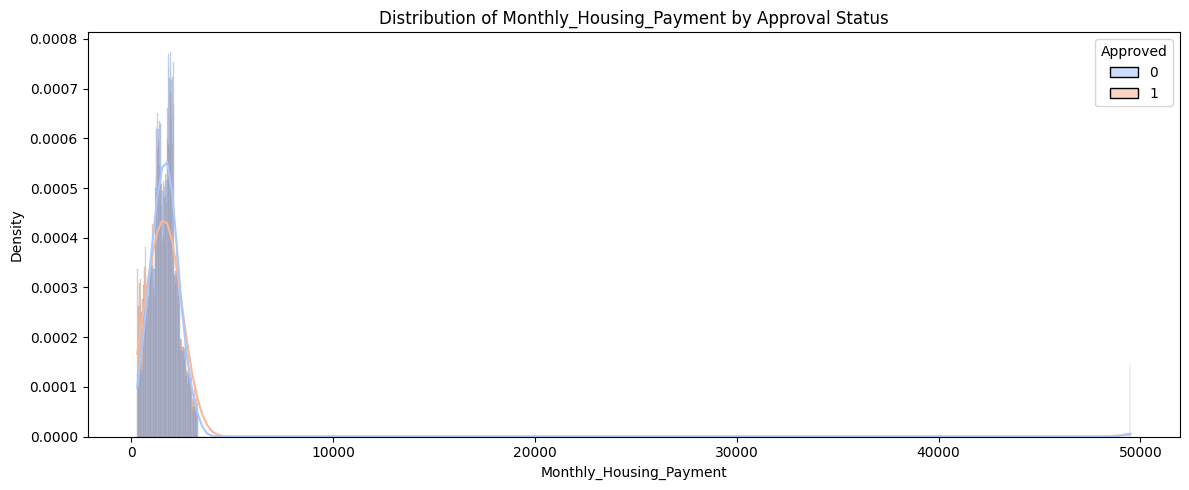

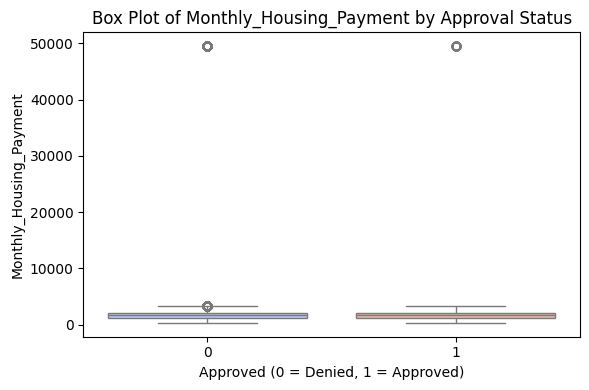

In [ ]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
Fico_score_group has strongest relationship with loan approval because it directly stated that people who has excellent score has highest approval rate of 45.80% compared to poor fico score approval, which is 2.78%. This variable strongly helps banks to differentiate between loan approval and rejection, as few people has loan approved with low fico score.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Reason has minimal predictive values across all categories as its highest variable credit card refinancing and lowest variable other has only 0.47 difference for approving loan due to car financing or for any other reason.This difference does not make much affect on loan approval process compared to approval rate by employment sector which has the difference value of 7.75 and fico_score_group whic has difference of 43.02.

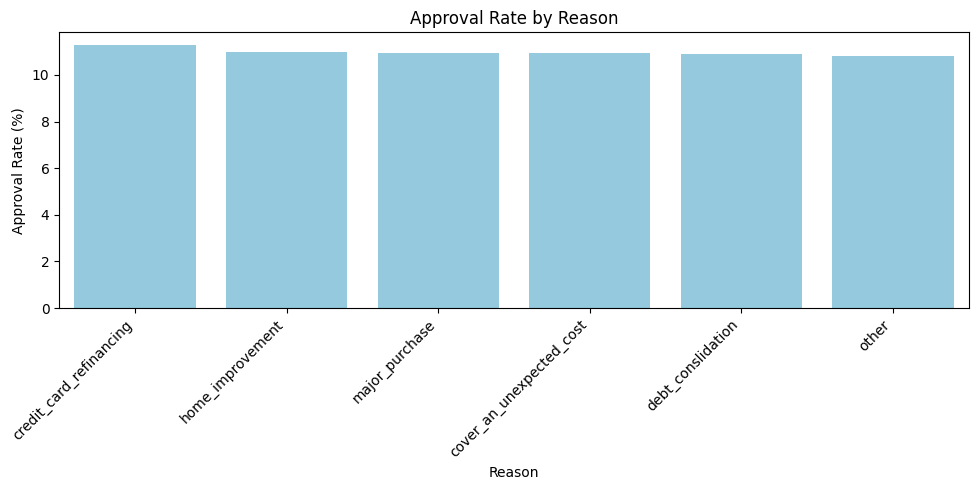


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


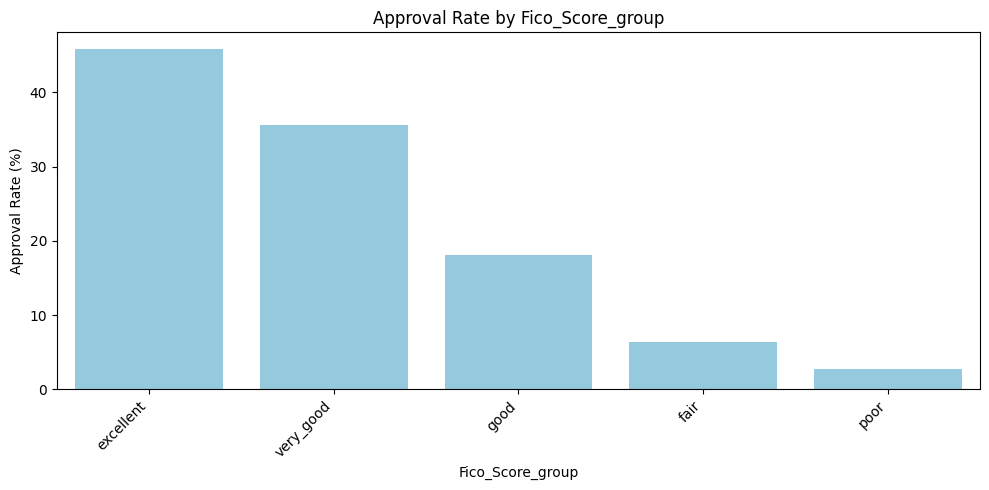


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


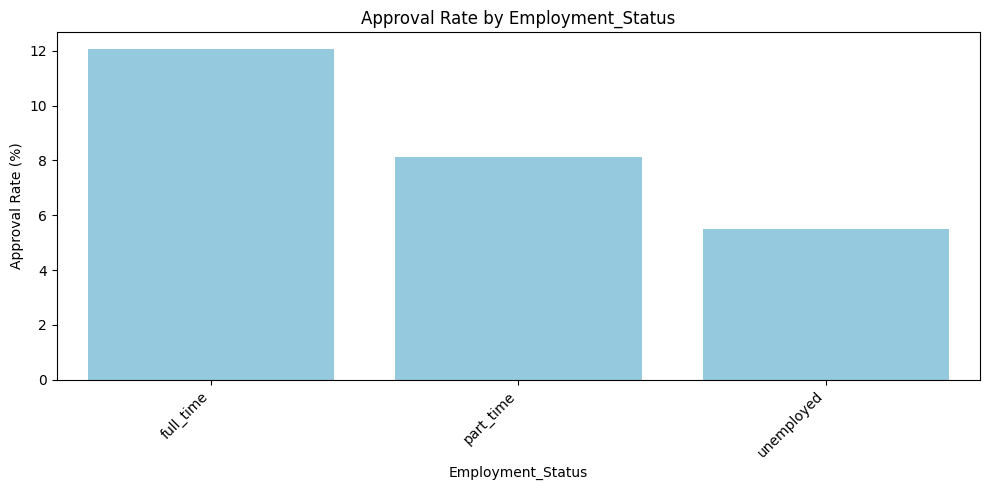


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


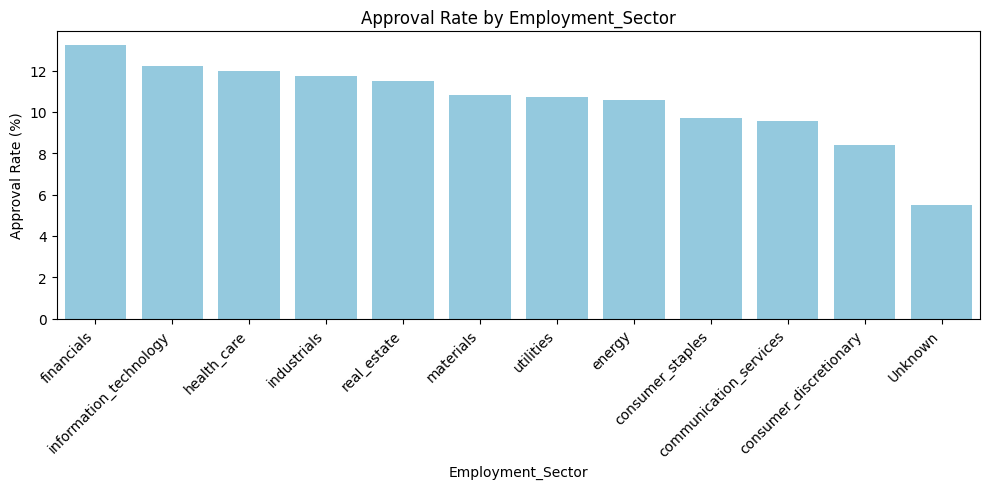


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Unknown                    5.49
Name: Approved, dtype: float64


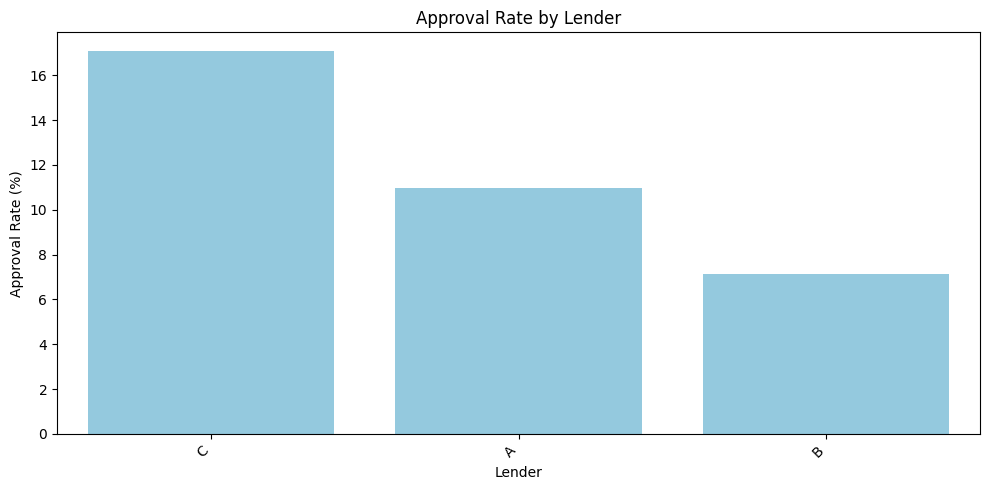


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


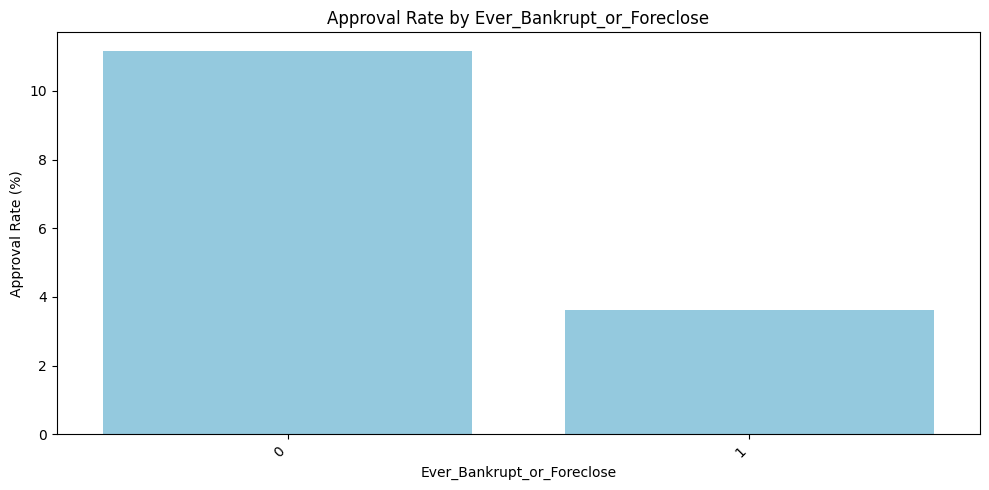


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [ ]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

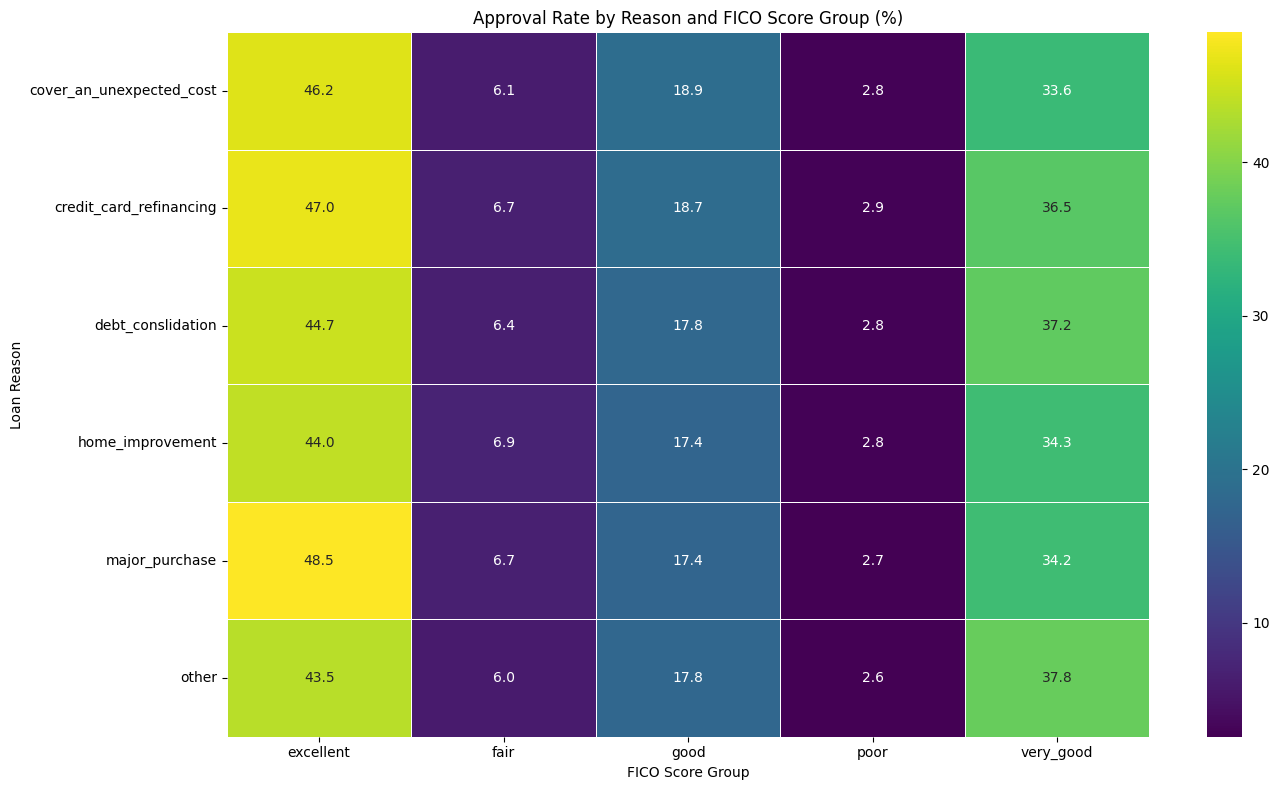

In [ ]:
approval_rates_cross = df.groupby(['Reason', 'Fico_Score_group'])['Approved'].mean().unstack() * 100

plt.figure(figsize=(14, 8))
sns.heatmap(approval_rates_cross, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title('Approval Rate by Reason and FICO Score Group (%)')
plt.xlabel('FICO Score Group')
plt.ylabel('Loan Reason')
plt.tight_layout()
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: The most helpful variables for approvals are the highest FICO score above 700-800, FICO_Score_group(excellent, good),Gross monthly income, Lender, and Ever_Bankrupt_or_Foreclose.

**FICO_Score_Group/ Fico score**: has the highest predictive value as it has a 43.02 spread and is the crucial factor to determine if a customer is going to get approved or denied for a bank loan. An excellent credit score (838) can make banks approve for any type of loan, as it gives them trust and reliability based on your previous credit history that you can pay off the loan without missing payments compared to good credit score (695) or low credit score where have to consider other factors for bank approval process like gross monthly income which shows ability to repay.

**Gross monthly income**: Banks use this to ensure you can pay. The overlapping histograms for income suggest that while it’s necessary to have income, a high salary won't approve loan with a poor FICO score.

**Approval rate by lender**: This variable has a 9.93 spread, which shows that there are different lenders from whom you can borrow, depending on the situation not relying on only 1. For example, when my parents bought a house, their lender had a very slow process and charged high interest but when my father researched he found a better lender with lowest interest rate and fast process for home loan.

**Approval rate by Ever_Bankrupt_or_Foreclosen**: this acts as very hard filter where a  single yes of being bankrupt ever can deny loan application regardless of additional factores like excellent fico score because this "being bankrupt" is a red flag for any loan process as previously you were unable to pay any loans offered by lendors so they wouldnot take any risk to offer you another loan. when comparing people with no bankruptcy has highest loan approval rate.

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Yes, I would add a debt-to-income ratio feature to see the affordability of a customer, like they earn 40,000 but have to only pay 5000
for a loan, compared to people who earn 40000 and have to pay 35000 for a loan, making them riskier for loan repayment.

**Question:** What is each lender’s average approval rate?  

**Answer**:

 Approval Rate by Lender:
C    17.06,
A    10.97,
B     7.13.

**Question:** Are there any clear differences between the three lenders in In terms of which types of customers they approve?  

**Answer**: Yes, there are differences between the three lenders in the type of customers they approve based on their risk tolerance. For example lender C has 17.06 loan approval rate which means he is a risk taker and gives loan to people who was rejected by oher lenders due to their lower fico score and is the lenient in approving loans but for lender B , the customer has to have excellent credit score to be approved for the loan with other considerable factors and is most selective oe as they do not want to take  risk and are 100% confident that their customer can repay the loan within time period.

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Yes, the specific fico score can predict a customer approval likelihood for particular lender for example FICO score of very good and excellent can predict a approval at lender B, FICO score of fair to excelent at lender C and fico score of good to excellent can be approved at lender A which is standard loan approval process bank where above 700 they approve the loan.



> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Rename your df to df_model.
df_model = df_clean.copy()

# Drop highly correlated and target-related variables as discussed in EDA
df_model = df_model.drop(columns=['Requested_Loan_Amount', 'Fico_Score_group'])

# Define features (X) and target (y)
X = df_model.drop(columns=['Approved', 'bounty'])
y = df_model['Approved']

# Apply one-hot encoding using pd.get_dummies
# drop_first=True to avoid multicollinearity
X = pd.get_dummies(X, drop_first=True)

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Use an 80% train / 20% test split, stratifying by 'Approved' to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_state, stratify=y)

# Define numerical columns to scale
# These are the original numerical columns that have not been one-hot encoded or dropped
num_cols_to_scale = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Initialize StandardScaler
scaler = StandardScaler()

# Create copies to avoid SettingWithCopyWarning and scale the numerical columns
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Data preprocessing complete. X_train_scaled, X_test_scaled, y_train, y_test are ready for modeling.")

Data preprocessing complete. X_train_scaled, X_test_scaled, y_train, y_test are ready for modeling.


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Accuracy**: The model is 69.46% accurate, telling us that 69.46% of loan applications in this set were classified correctly by the model.
**Predictive Strength**: It is important to look at the imbalance of the dataset, with 89% denied and 11% approved, our accuracy being 69.46% is not as strong as we would want it to be. A model that predicts no would technically be correct 89% of time.


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
logistic_model.fit(X_train_scaled, y_train)

print('Logistic Regression model trained.')

Logistic Regression model trained.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Evaluate Logistic Regression model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6946
Logistic Regression Precision: 0.2176
Logistic Regression Recall: 0.6999
Logistic Regression F1-Score: 0.3320
Logistic Regression ROC-AUC: 0.7661

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     17063
           1       0.22      0.70      0.33      2076

    accuracy                           0.69     19139
   macro avg       0.58      0.70      0.57     19139
weighted avg       0.87      0.69      0.75     19139


Confusion Matrix:
[[11840  5223]
 [  623  1453]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Define a custom cutoff threshold (e.g., 0.7)
# By default, it's 0.5. Lowering it will increase recall for the positive class (1) but might decrease precision.
custom_threshold = 0.7

# Get predicted probabilities for the positive class (Approved=1) from the Logistic Regression model
y_prob_lr_custom = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Apply the custom threshold to get new predictions
y_pred_lr_custom = (y_prob_lr_custom >= custom_threshold).astype(int)

print(f"\n--- Logistic Regression with Custom Threshold ({custom_threshold}) ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_custom))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_custom))



# You can now compare these metrics with the default threshold metrics printed above.


--- Logistic Regression with Custom Threshold (0.7) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     17063
           1       0.31      0.37      0.33      2076

    accuracy                           0.84     19139
   macro avg       0.61      0.63      0.62     19139
weighted avg       0.85      0.84      0.85     19139

Confusion Matrix:
[[15353  1710]
 [ 1316   760]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate Logistic Regression model with custom threshold
accuracy_lr_custom = accuracy_score(y_test, y_pred_lr_custom)
precision_lr_custom = precision_score(y_test, y_pred_lr_custom)
recall_lr_custom = recall_score(y_test, y_pred_lr_custom)
f1_lr_custom = f1_score(y_test, y_pred_lr_custom)
roc_auc_lr_custom = roc_auc_score(y_test, y_prob_lr_custom) # ROC-AUC remains the same as it's threshold-independent

print(f"Logistic Regression (Custom {custom_threshold}) Accuracy: {accuracy_lr_custom:.4f}")
print(f"Logistic Regression (Custom {custom_threshold}) Precision: {precision_lr_custom:.4f}")
print(f"Logistic Regression (Custom {custom_threshold}) Recall: {recall_lr_custom:.4f}")
print(f"Logistic Regression (Custom {custom_threshold}) F1-Score: {f1_lr_custom:.4f}")
print(f"Logistic Regression (Custom {custom_threshold}) ROC-AUC: {roc_auc_lr_custom:.4f}")

Logistic Regression (Custom 0.7) Accuracy: 0.8419
Logistic Regression (Custom 0.7) Precision: 0.3077
Logistic Regression (Custom 0.7) Recall: 0.3661
Logistic Regression (Custom 0.7) F1-Score: 0.3344
Logistic Regression (Custom 0.7) ROC-AUC: 0.7661


In [ ]:
import numpy as np
coefficients = logistic_model.coef_[0]
odds_ratios = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})
odds_ratios['Abs_Coefficient'] = np.abs(odds_ratios['Coefficient'])
odds_ratios = odds_ratios.sort_values(by='Abs_Coefficient', ascending=False).drop(columns='Abs_Coefficient')

print("\nOdds Ratios for Logistic Regression Model:")
print(odds_ratios)


Odds Ratios for Logistic Regression Model:
                                     Feature  Coefficient  Odds Ratio
4                 Ever_Bankrupt_or_Foreclose    -1.377151    0.252296
1                                 FICO_score     0.934829    2.546778
11              Employment_Status_unemployed    -0.934340    0.392845
24                                  Lender_C     0.869004    2.384536
23                                  Lender_B    -0.663078    0.515263
10               Employment_Status_part_time    -0.320053    0.726111
2                       Monthly_Gross_Income     0.215918    1.241001
0                        Granted_Loan_Amount    -0.166122    0.846943
19  Employment_Sector_information_technology     0.131260    1.140264
16              Employment_Sector_financials     0.123891    1.131893
3                    Monthly_Housing_Payment    -0.095551    0.908872
17             Employment_Sector_health_care     0.094426    1.099028
18             Employment_Sector_industrials  

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Trees accuracy and AUC compare to the Logistic Regression model?

**Answer**
The decision tree gives us an accuracy of 74.48%, which is slightly higher than the logistic regression model (0.5) that gives us 69.46% accuracy, but lower than logistic regression (0.7) at 84.19%.
The area under curves are very similar with decision tree at 0.7608 and logistic regression at 0.7661. This shows the logistic regression model is only slightly better at categorizing approved and denied loans.

**Decision trees automatically handle multicollinearity. We do not need to do additional steps, as it understands and distinguish complex relationships**

In [ ]:
# We use 'balanced' weights for imbalanced datasets
from sklearn.tree import DecisionTreeClassifier
dt_balanced = DecisionTreeClassifier(
    criterion="gini",  #faster
    max_depth=5,
    min_samples_split=10,     # need at least 10 samples to split
    min_samples_leaf=4,       # leaves must have 4 samples minimum
    max_features=None,  # for other examples with lots of predictors consider features at each split think of it as enforcing regularization
    class_weight='balanced',
    random_state=42           # reproducible results
)
dt_balanced.fit(X_train,y_train)
print('Decision Tree trained with balanced class weights.')

Decision Tree trained with balanced class weights.


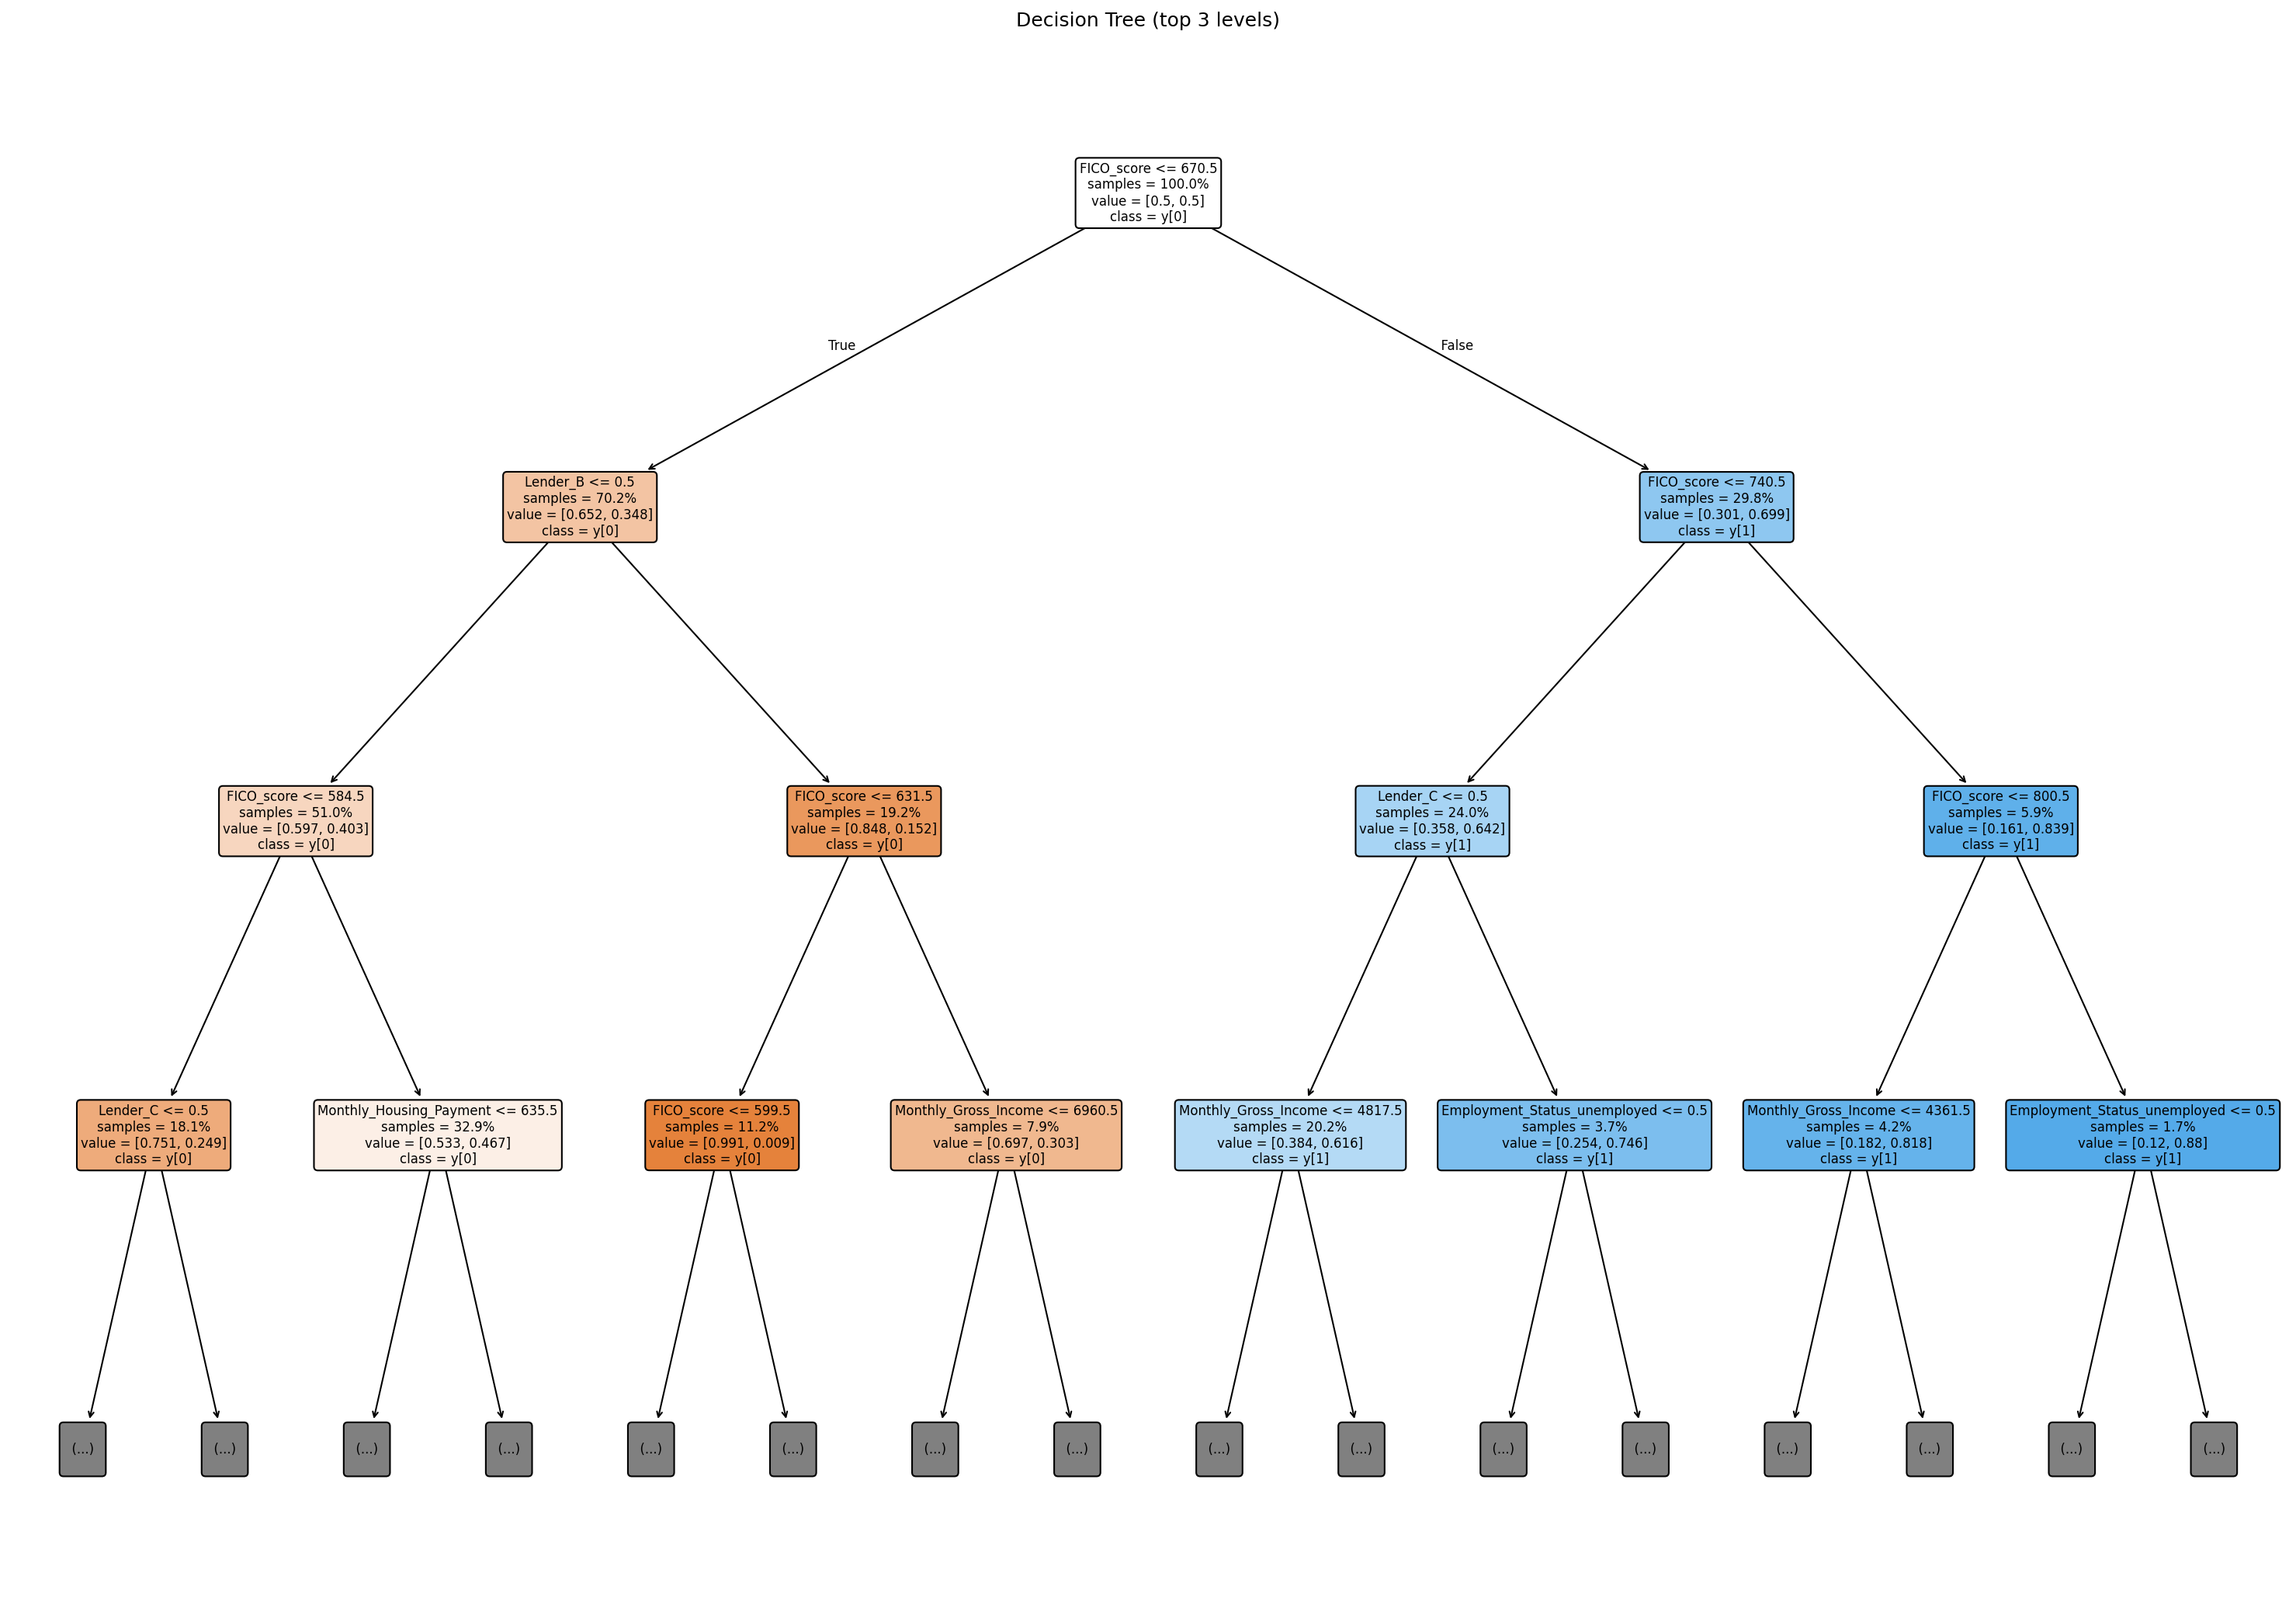

In [ ]:
import sklearn.tree
plt.figure(figsize=(20, 14), dpi=150)
sklearn.tree.plot_tree(
    dt_balanced,
    max_depth=3,           # limited to only the top 3 levels for clean visuals
    filled=True,
    rounded=True,
    impurity=False,        # hide gini/entropy text
    proportion=True,       # show class proportions
    feature_names=list(X_train.columns),
    class_names=True,
    fontsize=8
)
plt.title("Decision Tree (top 3 levels)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = dt_balanced.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))
# misclassification_rate_dt calculation moved to the next cell where accuracy_dt is defined.

              precision    recall  f1-score   support

           0       0.94      0.76      0.84     17063
           1       0.24      0.61      0.34      2076

    accuracy                           0.74     19139
   macro avg       0.59      0.68      0.59     19139
weighted avg       0.86      0.74      0.79     19139

[[12997  4066]
 [  819  1257]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set
y_pred_dt = dt_balanced.predict(X_test)
y_prob_dt = dt_balanced.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

misclassification_rate_dt = 1 - accuracy_dt

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")
print(f"Decision Tree F1-Score: {f1_dt:.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc_dt:.4f}")
print(f"Decision Tree Misclassification Rate: {misclassification_rate_dt:.4f}")

Decision Tree Accuracy: 0.7448
Decision Tree Precision: 0.2361
Decision Tree Recall: 0.6055
Decision Tree F1-Score: 0.3398
Decision Tree ROC-AUC: 0.7608
Decision Tree Misclassification Rate: 0.2552


Decision Tree Feature Importances:
                         feature  importance
1                     FICO_score    0.706802
23                      Lender_B    0.106324
2           Monthly_Gross_Income    0.058100
3        Monthly_Housing_Payment    0.057242
24                      Lender_C    0.037949
11  Employment_Status_unemployed    0.018687
0            Granted_Loan_Amount    0.011829
10   Employment_Status_part_time    0.003066
4     Ever_Bankrupt_or_Foreclose    0.000000
8          Reason_major_purchase    0.000000


/tmp/ipykernel_3764/3804395658.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_dt.head(10), palette='viridis')


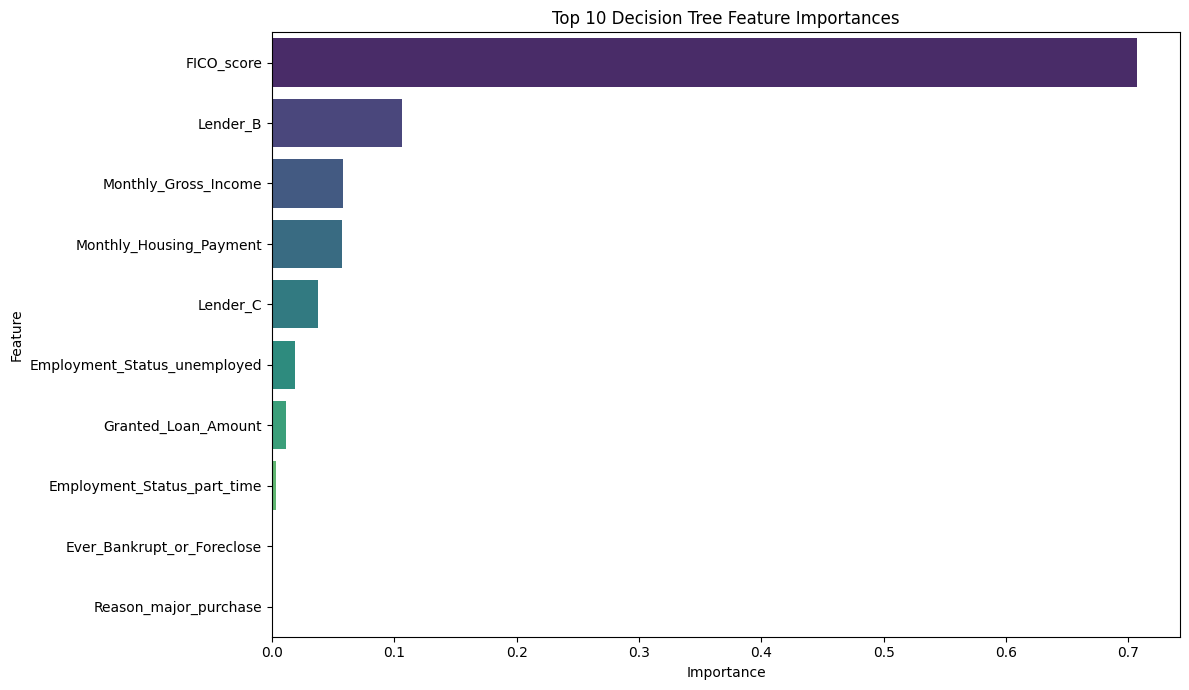

In [ ]:
# Feature importances for Decision Tree
feature_importances_dt = pd.DataFrame({'feature': X_train.columns, 'importance': dt_balanced.feature_importances_})
feature_importances_dt = feature_importances_dt.sort_values(by='importance', ascending=False)

print("Decision Tree Feature Importances:")
print(feature_importances_dt.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importances_dt.head(10), palette='viridis')
plt.title('Top 10 Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**FICO Score, Monthly Gross Income and Lender C are the top 3 features used for predicting loan approval using a decision tree model.**

### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.

The models perform very similarly, the decision tree is about 5% more accurate than our original logistical regression model, but the AUC of the logistic regression is slighlty higher. The model of logistic regression with the cutoff shows a higher accuracy (84.19%), and helps us become more strict, making sure there are less false approvals.

2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.

Comparing our decision tree to our logistic regression at 0.7, accuracy is 0.8419 for logistic regression and 0.7448 for decision tree, precision is 0.3077 for logistic and 0.2361 for decision tree, for area under curve, logistic regression is 0.7661 and decision tree is 0.7608, these three categories all show our cutoff logistic regression to outperform our decision tree. But, the decision tree does perform better in recall, 0.6055 and F-1 score 0.3398, than the logistic regression, 0.3661 and 0.3344. All these numbers show that the logistic regression model is more strict and reliable for catching false positives and improving accuracy.

3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).

In this sense, false positives and negatives are a key thing to look at when comparing models. A false positive in this sense is someone applying who may be a riskier client to accept, they should not get approved and may struggle to pay the loan back, putting our company at risk of losing this money. A false negative is someone who gets rejected, when they should have been accepted. They provide an opportunity for us to give them a loan, knowing they will pay it back, reducing risk. The only thing rejecting them wrongly does is minimize our profit. False positives are much worse because they put us at risk of losing money, where false negatives just don't make us money, but we won't technically lose any by not accepting them. Confusion matricies are included with the code in each model.

4. Identify which model best captures the target event (loan approval) and explain why.

Due to the recall number of the decision tree being higher than the logistic regression, it is better at capturing loan approval, but with this, there are more applicants that get falsely approved. With its accuracy being lower than our 0.7 threshold logistic regression, it is not as accurate so that is where the risk comes in.

5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.

From a technical point, like said above, we would use the decision tree. This is the model that categorizes more into loan approval correctly. Using this would help us give out more loans and this model do what its supposed to do in that sense, pick those individuals and approve them for loans. However, from a business perspective this is much more risky. Our logistic regression post cutoff model has a much higher accuracy, meaning many more correct predictions. There are less approvals in general, making it look worse in that sense, but it produces much less false positives. This cuts out the risk of accidentally giving people loans who shouldn't be approved and eliminating the risk of them not paying the loan back.

6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

This cutoff, 0.7, makes our model much more strict. In turn, our accuracy, precision and false approvals all get better. This is important to us because we don't want to falsely approve people that should not be approved. This does bring in more error of rejecting people who should not be rejected, but this is the way we would want to lean if we have to choose, in making sure we don't increase in the number of people who will get approved and not be able to pay our loan back.


In [ ]:
model = model = {'logistic_model': logistic_model, 'threshold': custom_threshold}

In [ ]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'Loan_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")


Model saved successfully to Loan_model.pkl


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**

If we were only able to use one model and had to choose from our one of our current tested options, I would choose the logistic regression model after cutoff, with the 0.7 threshold. This model is the most accurate by a significant amount at categorizing data into the correct section, at an 84.19% rate. Although we may see a higher recall score with this model than with our decision tree, we can guarantee the highest accuracy with this model. From a business standpoint, that is what we are looking to do: maximize the number of times in our dataset that an applicant or potential applicant is placed in the right category. It is also easier to interpret the reason for loan rejection by customers compared to explaining the complex process of decision trees

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**

While doing our analysis and comparison, looking at the results from the model we find that the logistical regression after the cutoff was the most accurate, but did not deal false positives and negatives well. The decision tree did a better job, based on its recall number, of minimizing false positives by a large margin. But, for our streamlit app we have to use logistic regression with the 0.7 threshold due to the significantly higher accuracy that it provides us. Our key factors that influence loan approval were FICO Score, which accounted for around 70% on our importance scale, monthly gross income at around 7% importance, monthly house payment at about 7% importance and then a combination of lender categories, combining for about 12%. Altogether, these are nearly 90% of the influence in our decision to approve a loan. Another thing to add to the strength of how important these are is the odds ratios. FICO score and Lender C have an odds ratio of over 2, meaning they are very strong positive predictors of whether or not we have a good candidate.
A recommendation that I have to propose to the company is to use a combination of both models. If it is possible, leverage the logistic regression model for its accuracy and the decision tree to prevent false positives and negatives. If we could leverage both of these, we could maximize the accuracy of approving those who we can be profitable off when we loan to them and minimze those who we should not loan to who may put us at risk. To analyze further, I would look into this and run some past applicants with a new model combining these two and look at a confusion matrix to see how the numbers compare to our current models. I understand that this is not possible from a standpoint of this specific project and our streamlit app but if I were working with the company this would be the recommendation that I would propose to management. We have different models that are good at leveraging certain data, and only using one limits us in what we are able to do.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:**
The risks and trade-offs that the company need to be aware of in this model is that not every single categorization of applicants will be the right decision. With a model like this, there is variance. Some clients will get falsely approved, while some will get falsely denied. This unfortunately does not maximize the amount of profit that we could possibly make, and it also puts us at risk in some scenarios that we may falsely approve someone who will not be able to repay their loan and will cost us money.In using the logistic regression, we are bound to get more accurate categorizations but the company should be aware of the increase in recall that comes with that.

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:**
We are confident that our model's could, if it had the right data from individuals, work in the real world outside of our test dataset. If we were able to get the information for new potential applicants, we could run it through our model, and get an idea of whether or not they would fit into our criteria of offering them a loan or denying them. It would be important that we get true information from each of these applicants.

**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:**
If I had access to more data and could use it in my models, I would strengthen it by using past results to train present applications. I would leverage old applicants and their status, approved or denied and use parts of their application to strengthen the process that the model goes through. More steps in the model and application process will help us with accuracy, to make sure we can accurately devote the applicants to the right categories.

** Streamlit App Link Below:**

Streamlit app:https://loan-approval-optimization-kukndp7dxm6xv33pwjyv9y.streamlit.app/

Github Link : https://github.com/mohammadi2026/loan-approval-optimization

